In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00


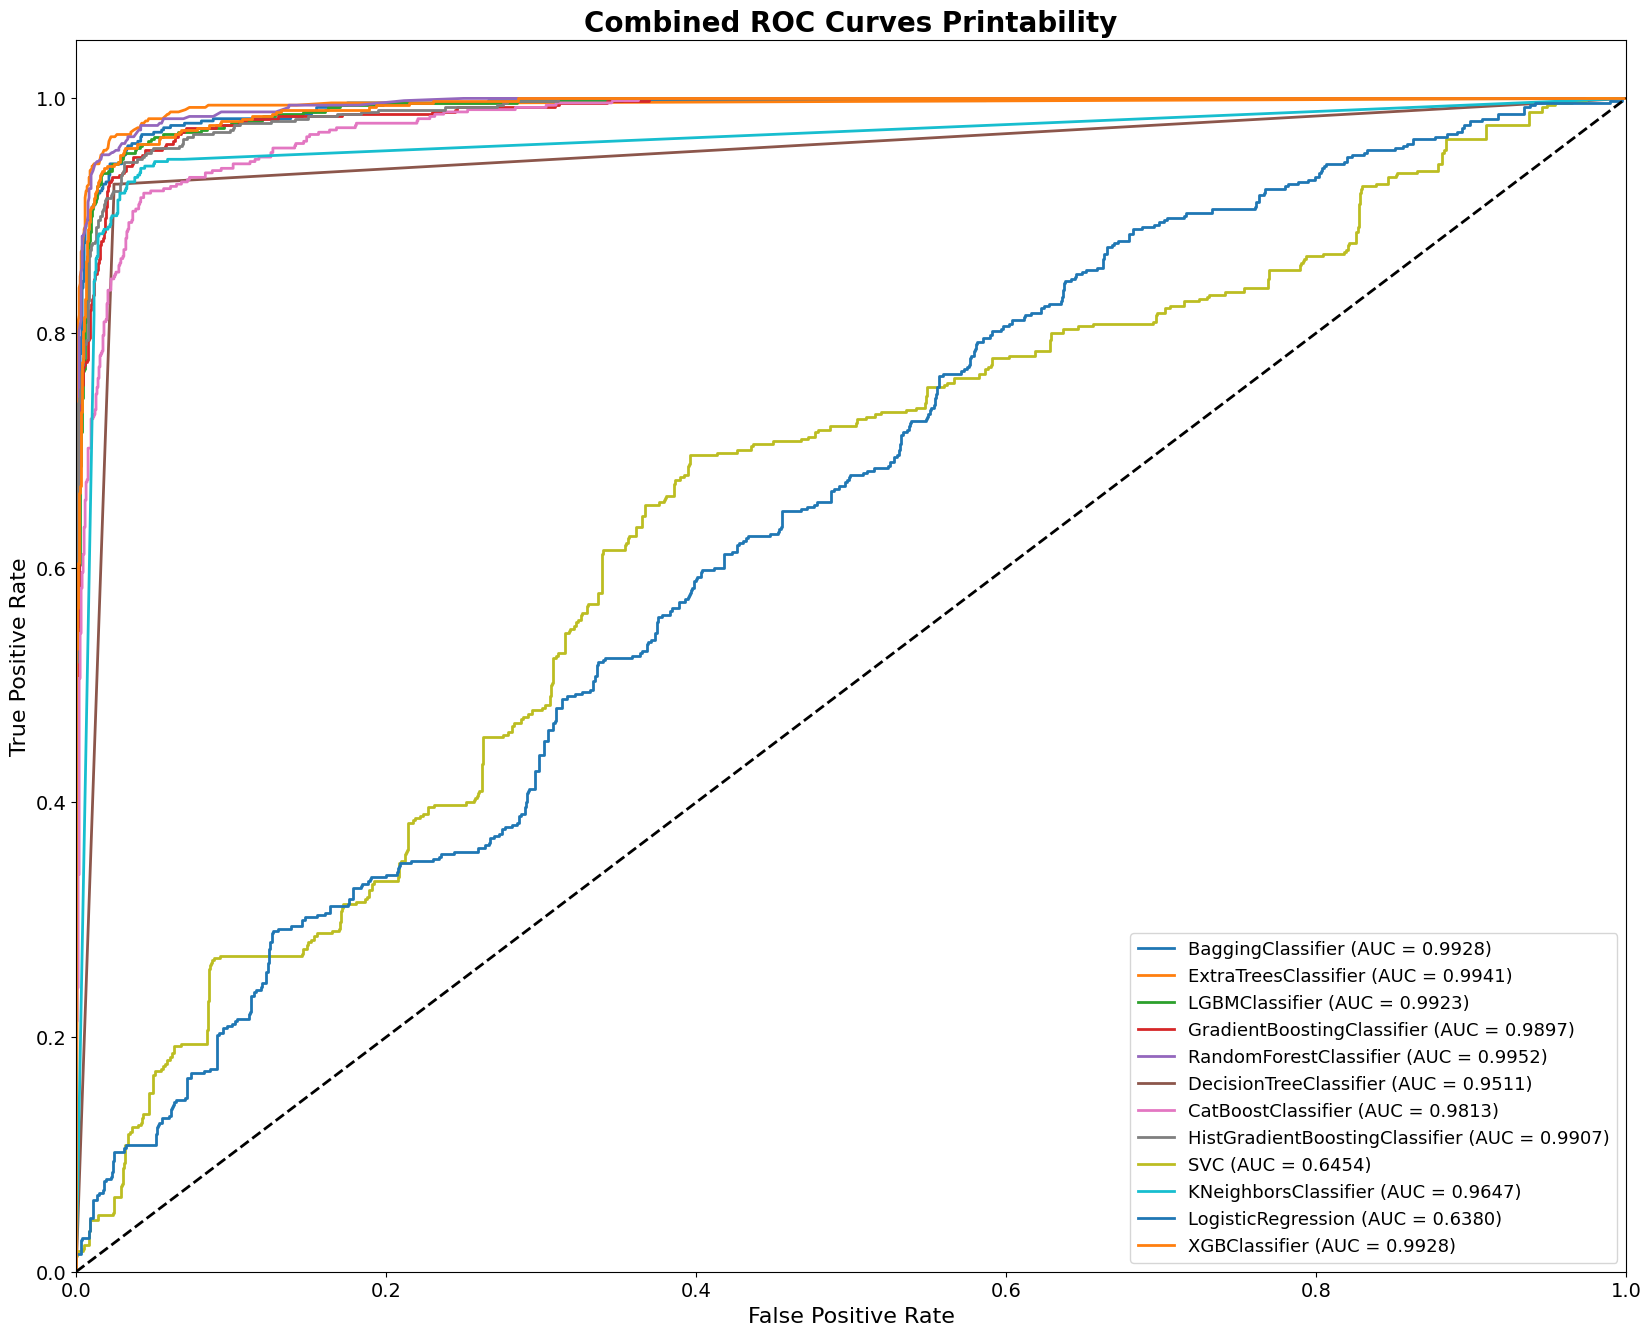

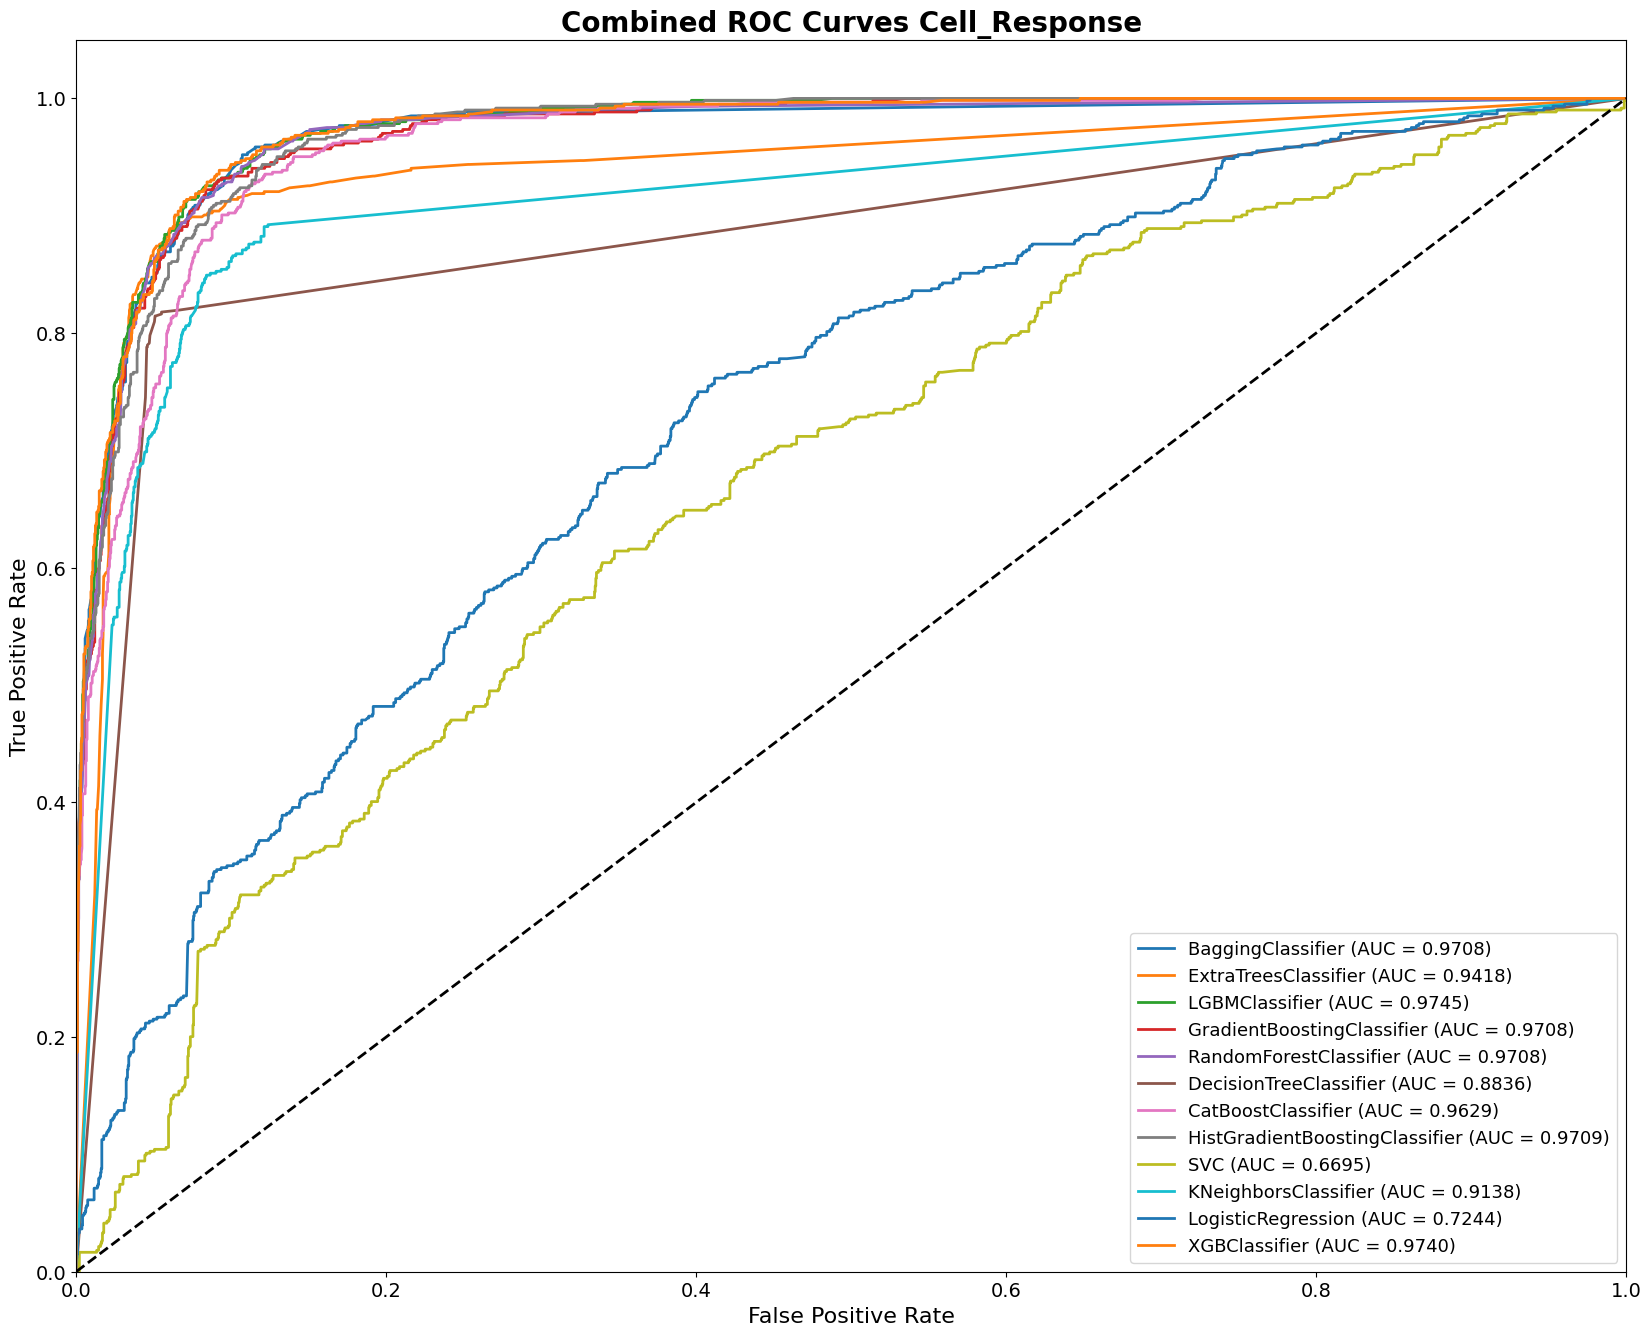

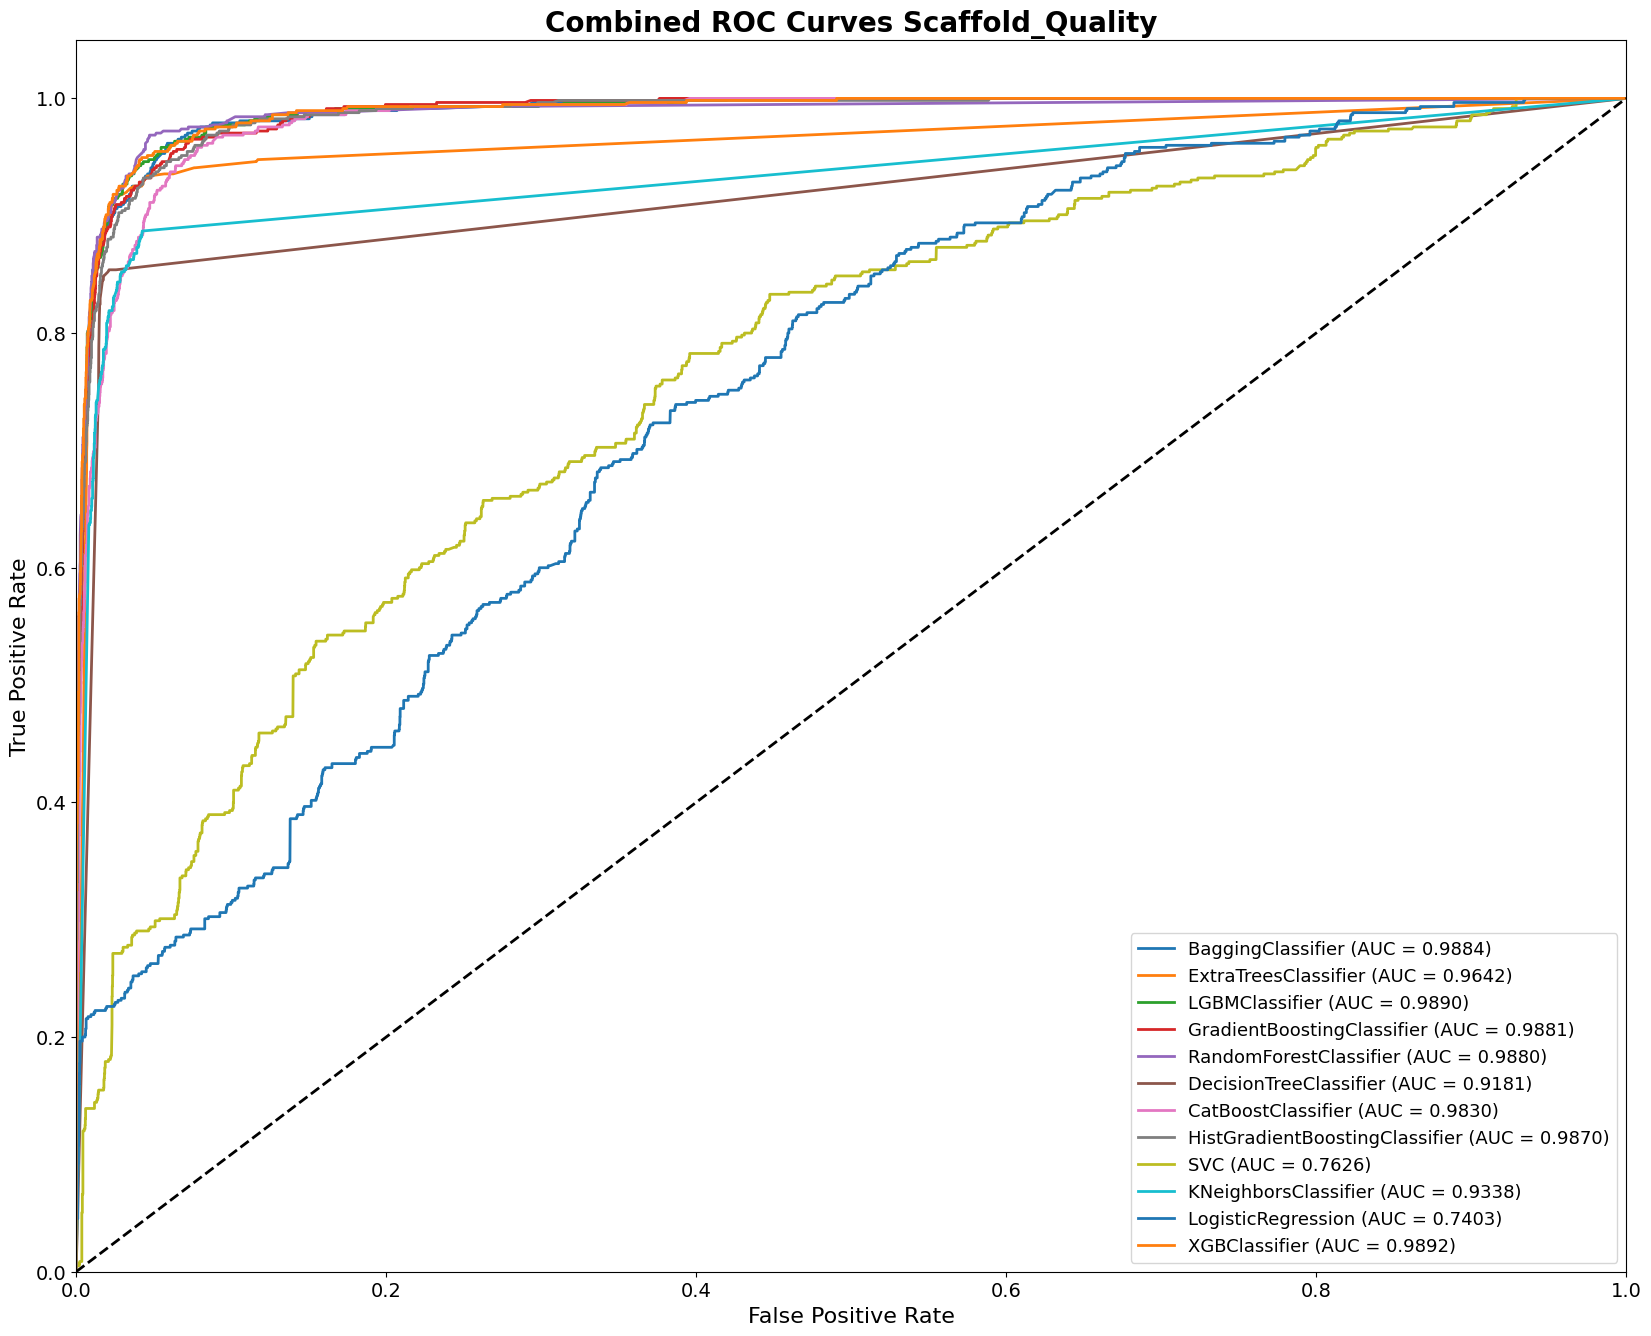

In [ ]:
import os
import json
import ast
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc

import warnings
warnings.filterwarnings("ignore")

dfs = {
    'Printability' : 'Printability_resampled_df.csv',
    'Cell_Response' : 'Cell_Response_resampled_df.csv',
    'Scaffold_Quality' : 'Scaffold_Quality_(PxC)_resampled_df.csv'
}

for item in dfs.keys():
    df = pd.read_csv(dfs[item])

    X = df.iloc[:, :-1]
    y = df.iloc[:, -1:].values.ravel()

    unique_values = np.unique(y)
    value_to_continuous = {original_value: new_value for new_value, original_value in enumerate(unique_values)}
    y_continuous = np.array([value_to_continuous[value] for value in y])
    y = y_continuous

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    # Scaling
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Convert back to DataFrame with original column names
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

    # Step 2: Initialize ROC data list
    roc_data_list = []

    # Step 3: Binarize the output for ROC
    y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
    n_classes = y_test_binarized.shape[1]

    result_df = pd.read_csv(f'results for {item}.csv')

    # Step 4: Plot ROC Curves
    plt.figure(figsize=(20, 16))

    for index, row in result_df.iterrows():
      name = row['Classifier']
      params_str = row['Best Params']  # Get the string representation of parameters

      # Assuming params_str is a dictionary-like string, convert it to a dictionary
      try:
          params = ast.literal_eval(params_str)
      except (SyntaxError, ValueError):
          print(f"Could not parse parameters for {name}. Skipping...")
          continue

      # Initialize the model based on the classifier name
      if name == 'DecisionTreeClassifier':
          model = DecisionTreeClassifier(**params)
      elif name == 'ExtraTreesClassifier':
          model = ExtraTreesClassifier(**params)
      elif name == 'RandomForestClassifier':
          model = RandomForestClassifier(**params)
      elif name == 'GradientBoostingClassifier':
          model = GradientBoostingClassifier(**params)
      elif name == 'BaggingClassifier':
          model = BaggingClassifier(**params)
      elif name == 'SVC':
          model = SVC(probability = True, **params)
      elif name == 'LGBMClassifier':
          params['verbosity'] = -1
          model = LGBMClassifier(**params)
      elif name == 'XGBClassifier':
          model = XGBClassifier(**params)
      elif name == 'CatBoostClassifier':
          params['verbose'] = 0
          model = CatBoostClassifier(**params)
      elif name == 'HistGradientBoostingClassifier':
          model = HistGradientBoostingClassifier(**params)
      elif name == 'KNeighborsClassifier':
          model = KNeighborsClassifier(**params)
      elif name == 'LogisticRegression':
          model = LogisticRegression(**params)

      else:
          print(f"Unsupported classifier: {name}. Skipping...")
          continue

      # Train the model
      model.fit(X_train, y_train)

      # Predict probabilities
      y_proba = model.predict_proba(X_test)

      # Flatten the arrays to calculate global ROC
      fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), y_proba.ravel())
      roc_auc = auc(fpr, tpr)

      # Plot ROC Curve
      plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

      # Save ROC data
      roc_data = {'Classifier': name, 'FPR': fpr.tolist(), 'TPR': tpr.tolist(), 'AUC': roc_auc}
      roc_data_list.append(roc_data)

    # Step 5: Final ROC figure touches
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.title(f'Combined ROC Curves {item}', fontsize=20, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", fontsize=13)
    plt.show()